In [3]:
from grid_generator import *
from wrp_solver import *
from wrp_solver_opt import *
from utils import *
from autoregressive_unet import *
import matplotlib.pyplot as plt
from tqdm import tqdm
from data_generator import *
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import os
import random

# ---------- Global device config ----------
# Set to one of: "auto", "mps", "cuda", "cpu"
DEVICE_PREF = "mps"

def resolve_device(pref=DEVICE_PREF):
    pref = pref.lower()
    if pref == "auto":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")
    if pref == "mps":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        print("Warning: MPS requested but not available. Falling back to CPU.")
        return torch.device("cpu")
    if pref == "cuda":
        if torch.cuda.is_available():
            return torch.device("cuda")
        print("Warning: CUDA requested but not available. Falling back to CPU.")
        return torch.device("cpu")
    return torch.device("cpu")

DEVICE = resolve_device()
print(f"Using device: {DEVICE}")

Using device: mps


Generated Grid:


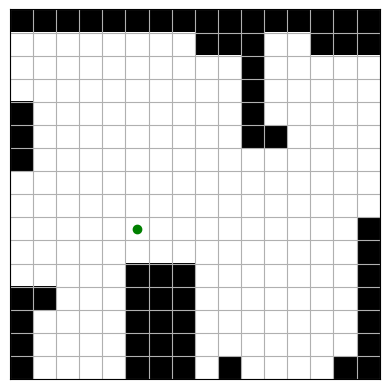

In [4]:
# Generate a random grid
gen = WRPDataGenerator(16, 16)
# grid, start = gen.generate_valid_grid(density=5)
grid, start = gen.generate_simple_polygon_grid()
print("Generated Grid:")

plot_grid(grid, start)


In [5]:
grid

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1],
       [1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1],
       [1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1],
       [1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1],
       [1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1]], dtype=int8)

Optimized Path Length: 42


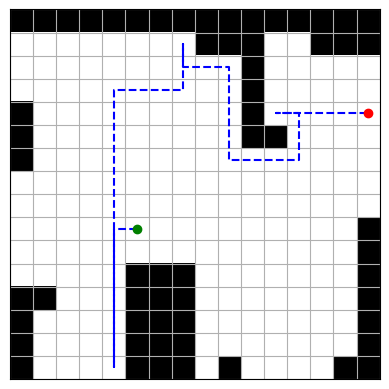

In [6]:
solver_opt = WRPSolverTSPJF(grid, start)
path_opt, cnt_opt = solve_wrp_tsp_jf(solver_opt)

print("Optimized Path Length:", len(path_opt))

plot_path(grid, path_opt, start)

In [20]:
# from scipy.ndimage import binary_dilation # ADD THIS IMPORT
def generate_training_data_for_online_learning(grid, offline_path):
    """
    Generate training data for online learning by simulating the execution of the offline path and recording the state transitions.
    
    Args:
        grid (np.ndarray): The grid representation of the environment.
        offline_path (list of tuples): The path generated by the offline solver.
    Returns:
        3 Channel Tensor:

        Channel 0: 
            Known Obstacles ::
            What it is: The physical walls the agent has actually seen with its Line of Sight (LOS).
            The Math: If a cell is an obstacle AND it has been observed, value = 1.0. Otherwise, value = 0.0.
            Note: At step 0, this channel might be almost entirely zeros, except for the walls immediately surrounding the start position.
        Channel 1: 
            Agent Position ::
            What it is: The exact current location of the agent.
            The Math: A strict one-hot tensor. The single cell where the agent is standing is 1.0. All other 255 cells are 0.0.
        Channel 2: 
            Unseen Map ::
            What it is: The strictly unknown space that the agent's LOS has never touched.
            The Math: If a cell has NEVER been seen, value = 1.0. If a cell HAS been seen (regardless of whether it turned out to be free space or a wall), value = 0.0.
    """

    # Initialize the 3-channel tensor
    X, y = [], []
    
    # Simulate the agent's movement along the offline path
    for step in range(len(offline_path) - 1):
        # Create empty channels
        known_obstacles = np.zeros_like(grid, dtype=np.float32)
        agent_position = np.zeros_like(grid, dtype=np.float32)
        unseen_map = np.ones_like(grid, dtype=np.float32)  # Start with everything unknown
        
        # Get current position of the agent
        current_pos = offline_path[step]
        
        # Update agent position channel (one-hot)
        agent_position[current_pos] = 1.0
        
        # Simulate Line of Sight (LOS) from the current position
        expanded_los = get_LOS4_visibility_map(grid, offline_path[:step+1], with_last_obstacle=True)
        unseen_map[expanded_los == 1] = 0.0  # This cell has been seen

        # 1. Expand the visible free space by 1 pixel to "touch" the adjacent walls
        # 2. If a cell is touched by the expanded LOS AND it is a wall in the real grid,
        # it is now a Known Obstacle.
        visible_walls = expanded_los & (grid == 1)
        known_obstacles[visible_walls] = 1.0
        
        # Combine channels into a single tensor for this step
        state_tensor = np.stack([known_obstacles, agent_position, unseen_map], axis=0)
        X.append(state_tensor)

        target_tensor = np.zeros((1, grid.shape[0], grid.shape[1]), dtype=np.float32)
        next_pos = offline_path[step + 1]
        target_tensor[0, next_pos[0], next_pos[1]] = 1.0
        y.append(target_tensor)
    
    return np.array(X), np.array(y)


In [26]:
from data_generator import _solve_grid
def generate_N_training_data_for_online_learning(num_samples, grid_size=(16, 16), density=5, timeout=300):
    X_list = []
    y_list = []
    skipped = 0
    
    for _ in tqdm(range(num_samples)):
        # Generate a random grid and path
        gen = WRPDataGenerator(*grid_size)
        # grid, start = gen.generate_valid_grid(density=density)
        grid, start = gen.generate_simple_polygon_grid()
        
        try:
            path_opt, _ = run_with_timeout(_solve_grid, args=(grid, start), timeout=timeout)
        except TimeoutError:
            skipped += 1
            continue
        
        # Generate training data from the path
        X, y = generate_training_data_for_online_learning(grid, path_opt)
        X_list.append(torch.tensor(X, dtype=torch.float32))
        y_list.append(torch.tensor(y, dtype=torch.float32))
    
    if skipped:
        print(f"Skipped {skipped}/{num_samples} samples due to timeout ({timeout}s)")
    
    return torch.cat(X_list), torch.cat(y_list)


In [21]:
# X_train, y_train = generate_N_training_data_for_online_learning(200)
# print("Generated training data shapes:", X_train.shape, y_train.shape)
# save_data_to_disk(X_train, y_train, "data/wrp_online_data_16x16_200_samples_SP_train.pt")

# X_val, y_val = generate_N_training_data_for_online_learning(50)
# print("Generated validation data shapes:", X_val.shape, y_val.shape)
# save_data_to_disk(X_val, y_val, "data/wrp_online_data_16x16_51_samples_SP_test.pt")

In [95]:
X_train1, y_train1 = load_data_from_disk("data/wrp_online_data_16x16_1000_samples_SP_train.pt")
X_train2, y_train2 = load_data_from_disk("data/wrp_online_data_16x16_1000_samples_SP_train2.pt")
X_train3, y_train3 = load_data_from_disk("data/wrp_online_data_16x16_500_samples_SP_train.pt")


X_test, y_test = load_data_from_disk("data/wrp_online_data_16x16_100_samples_SP_test.pt")
    
X_train, y_train = torch.cat([X_train1, X_train2, X_train3]), torch.cat([y_train1, y_train2, y_train3])
print("Final training data shape:", X_train.shape, y_train.shape)

Loaded 33696 samples from data/wrp_online_data_16x16_1000_samples_SP_train.pt
X shape: (33696, 3, 16, 16) | y shape: (33696, 1, 16, 16)
Loaded 34812 samples from data/wrp_online_data_16x16_1000_samples_SP_train2.pt
X shape: (34812, 3, 16, 16) | y shape: (34812, 1, 16, 16)
Loaded 16720 samples from data/wrp_online_data_16x16_500_samples_SP_train.pt
X shape: (16720, 3, 16, 16) | y shape: (16720, 1, 16, 16)
Loaded 3511 samples from data/wrp_online_data_16x16_100_samples_SP_test.pt
X shape: (3511, 3, 16, 16) | y shape: (3511, 1, 16, 16)
Final training data shape: torch.Size([85228, 3, 16, 16]) torch.Size([85228, 1, 16, 16])


In [96]:
X_train_aug, y_train_aug = augment_data(X_train, y_train)
print("Augmented training data shapes:", X_train_aug.shape, y_train_aug.shape)

Augmented training data shapes: torch.Size([681824, 3, 16, 16]) torch.Size([681824, 1, 16, 16])


In [97]:
model = UNet16x16(in_channels=3, out_channels=1)
dummy_input = torch.randn(1, 3, 16, 16)
output = model(dummy_input)
print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}") 

Input shape: torch.Size([1, 3, 16, 16])
Output shape: torch.Size([1, 1, 16, 16])


In [98]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import torch
import torch.nn as nn
import torch.nn.functional as F

class SoftFocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, epsilon=1e-7):
        super(SoftFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

    def forward(self, preds, targets):
        # Clamp predictions to prevent log(0) resulting in NaN
        preds = torch.clamp(preds, self.epsilon, 1.0 - self.epsilon)

        # Standard Cross Entropy for continuous targets
        ce_loss_pos = -targets * torch.log(preds)
        ce_loss_neg = -(1.0 - targets) * torch.log(1.0 - preds)

        # Apply the Focal Loss modulating factors
        focal_term_pos = torch.pow(1.0 - preds, self.gamma)
        focal_term_neg = torch.pow(preds, self.gamma)

        # Combine and apply class balancing (alpha)
        loss_pos = self.alpha * focal_term_pos * ce_loss_pos
        loss_neg = (1.0 - self.alpha) * focal_term_neg * ce_loss_neg

        loss = loss_pos + loss_neg
        # return loss.mean()
        return loss.sum(dim = (1, 2, 3)).mean()  # Sum over channels and spatial dimensions, keep batch mean dimension

def train_unet(X_train, y_train, X_val, y_val, model, num_epochs=50, batch_size=32, lr=1e-3, device=DEVICE):
    # Setup Device
    print(f"Training on: {device}")
    model = model.to(device)

    # Setup DataLoaders
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Loss and Optimizer
    criterion = SoftFocalLoss(alpha=0.75, gamma=2.0) # High alpha to heavily weight the path pixels
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    
    # Cosine Annealing scheduler helps the model settle into local minima smoothly
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_val_acc = 0.0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            # Forward pass
            optimizer.zero_grad()
            preds = model(batch_X)
            
            # Loss calculation
            loss = criterion(preds, batch_y)
            
            # Backward and optimize
            loss.backward()
            
            # Gradient clipping prevents exploding gradients in deep U-Nets
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * batch_X.size(0)

            # Calculate Top-1 Action Accuracy
            # Flatten to (Batch, 256)
            preds_flat = preds.view(batch_X.size(0), -1)
            targets_flat = batch_y.view(batch_y.size(0), -1)
            
            # Find the index of the max probability
            pred_actions = preds_flat.argmax(dim=1)
            true_actions = targets_flat.argmax(dim=1)
            
            train_correct += (pred_actions == true_actions).sum().item()
            train_total += batch_X.size(0)

        # Validation Phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                preds = model(batch_X)
                
                loss = criterion(preds, batch_y)
                val_loss += loss.item() * batch_X.size(0)

                preds_flat = preds.view(batch_X.size(0), -1)
                targets_flat = batch_y.view(batch_y.size(0), -1)
                
                pred_actions = preds_flat.argmax(dim=1)
                true_actions = targets_flat.argmax(dim=1)
                
                val_correct += (pred_actions == true_actions).sum().item()
                val_total += batch_X.size(0)

        # Epoch Metrics
        train_loss /= len(train_loader.dataset)
        val_loss /= len(val_loader.dataset)
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"LR: {scheduler.get_last_lr()[0]:.6f} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # # Save the best model strictly based on Top-1 Action Accuracy
        # if val_acc > best_val_acc:
        #     best_val_acc = val_acc
        #     torch.save(model.state_dict(), 'best_wrp_unet.pth')
        #     print(f"--> Saved New Best Model (Acc: {val_acc:.4f})")

        scheduler.step()

    print("Training Complete.")
    return model

In [99]:
# model = UNet16x16(in_channels=3, out_channels=1)
# trained_model = train_unet(X_train_aug, y_train_aug, X_test, y_test, model, num_epochs=3, batch_size=64)

Training on: mps
Epoch [1/3] LR: 0.001000 | Train Loss: 0.1223 | Train Acc: 0.7702 | Val Loss: 0.1055 | Val Acc: 0.7981
Epoch [2/3] LR: 0.000750 | Train Loss: 0.1032 | Train Acc: 0.8001 | Val Loss: 0.1019 | Val Acc: 0.8052
Epoch [3/3] LR: 0.000250 | Train Loss: 0.0945 | Train Acc: 0.8163 | Val Loss: 0.1006 | Val Acc: 0.8063
Training Complete.


In [100]:
# trained_model.to("cpu")  # Move to CPU before saving for broader compatibility
# torch.save(trained_model.state_dict(), "model_online_16x16_ResAttARUnet.pth")
# trained_model.to(DEVICE)

UNet16x16(
  (inc): ResidualConv(
    (conv1): Conv2d(5, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dropout): Dropout2d(p=0.0, inplace=False)
    (shortcut): Sequential(
      (0): Conv2d(5, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (down1): Sequential(
    (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (1): ResidualConv(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kerne

In [101]:
trained_model = UNet16x16()
model_state_dict = torch.load("model_online_16x16_ResAttARUnet.pth")
trained_model.load_state_dict(model_state_dict)
trained_model.to(DEVICE)

UNet16x16(
  (inc): ResidualConv(
    (conv1): Conv2d(5, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dropout): Dropout2d(p=0.0, inplace=False)
    (shortcut): Sequential(
      (0): Conv2d(5, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (down1): Sequential(
    (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (1): ResidualConv(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kerne

In [102]:
trained_model.eval()
with torch.no_grad():
    output = trained_model(X_test.to(DEVICE)).cpu()

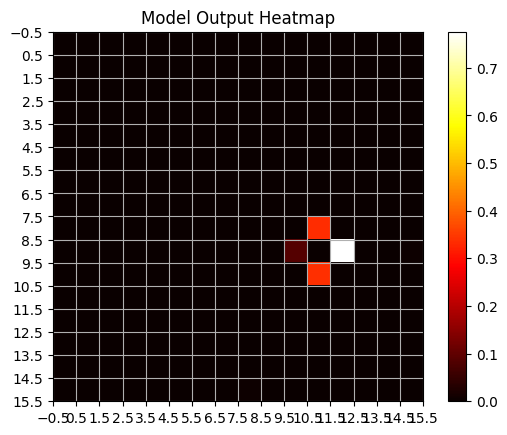

In [103]:
plot_output_tensor(output[12])

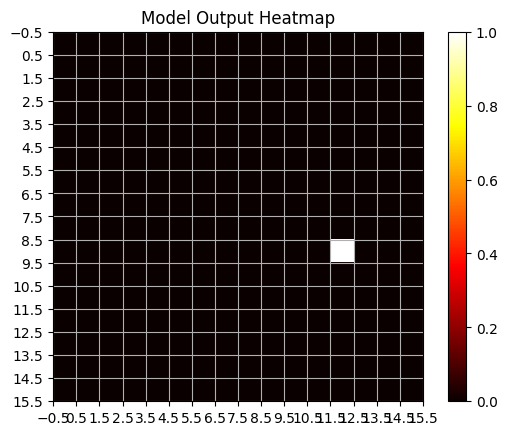

In [104]:
plot_output_tensor(y_test[12])

In [105]:
## Testing

## Testing

In [206]:
def pred_path_greedy_online(model, grid, start, max_steps=256, verbose = True):
    model.eval()
    current_pos = start
    path = [current_pos]
    H, W = grid.shape
    visited_counts = np.zeros((H, W))
    visited_counts[start[0], start[1]] = 1
    dataX =[]
    dataY =[]
    
    for _ in range(max_steps):
        # Create input tensor for the current state
        known_obstacles = np.zeros_like(grid, dtype=np.float32)
        agent_position = np.zeros_like(grid, dtype=np.float32)
        unseen_map = np.ones_like(grid, dtype=np.float32)  # Start with everything unknown
        
        agent_position[current_pos] = 1.0
        
        expanded_los = get_LOS4_visibility_map(grid, path, with_last_obstacle=True)
        unseen_map[expanded_los == 1] = 0.0

        visible_walls = expanded_los & (grid == 1)
        known_obstacles[visible_walls] = 1.0
        
        # --- Thes Termination Condition ---
        # --- THE TRUE ONLINE TERMINATION CONDITION ---
        # The agent checks if any known floor tile touches fog. 
        # If none exist, the enclosed polygon is 100% explored.
        is_done = True
        for r in range(H):
            for c in range(W):
                if known_obstacles[r, c] == 0.0 and unseen_map[r, c] == 0.0:  # If it is a known floor
                    for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                        nr, nc = r + dr, c + dc
                        if 0 <= nr < H and 0 <= nc < W and unseen_map[nr, nc] == 1.0:
                            is_done = False  # Found a frontier! We are not done.
                            break
                if not is_done: break
            if not is_done: break
            
        if is_done:
            if verbose:
                print(f"Success! Entire polygon explored in {_} steps.")
            break
        # -----------------------------------------------

        state_tensor = np.stack([known_obstacles, agent_position, unseen_map], axis=0)
        state_tensor = torch.tensor(state_tensor, dtype=torch.float32).unsqueeze(0).to(DEVICE)

        # Get model prediction
        with torch.no_grad():
            pred = model(state_tensor).cpu().numpy()[0, 0]  # Shape: (16, 16)

        # --- Physically Constrained Action Selection ---
        neighbors = [
            (current_pos[0]-1, current_pos[1]), # Up
            (current_pos[0]+1, current_pos[1]), # Down
            (current_pos[0], current_pos[1]-1), # Left
            (current_pos[0], current_pos[1]+1)  # Right
        ]
        
        best_prob = -float('inf')
        best_next_pos = current_pos
        
        for r, c in neighbors:
            # Check grid boundaries
            if 0 <= r < grid.shape[0] and 0 <= c < grid.shape[1]:
                # Check that we don't walk into a KNOWN wall
                if known_obstacles[r, c] != 1.0:
                    # Find the highest probability among valid neighbors
                    prob = pred[r, c]
                    penalty = visited_counts[r, c] * 0.4  # Penalize revisiting cells
                    score = prob - penalty
                    if score > best_prob:
                        best_prob = score
                        best_next_pos = (r, c)
                        
        if best_next_pos == current_pos:
            print("Model predicted to stay in place or is trapped. Ending path.")
            break
        # ---------------------------------------------------------
        
        path.append(best_next_pos)
        current_pos = best_next_pos

        visited_counts[current_pos[0], current_pos[1]] += 1
        dataX.append(state_tensor.cpu().numpy())
        dataY.append(pred)

    return path, (dataX, dataY)



import numpy as np
import torch
import heapq

def local_astar(start, goal, known_obstacles):
    """
    Standard A* that ONLY routes through known free space.
    """
    def heuristic(a, b):
        return abs(a[0] - b[0]) + abs(a[1] - b[1])
        
    neighbors = [(0, 1), (0, -1), (1, 0), (-1, 0)]
    open_set = []
    heapq.heappush(open_set, (0, start))
    came_from = {}
    
    g_score = {start: 0}
    f_score = {start: heuristic(start, goal)}
    
    while open_set:
        current = heapq.heappop(open_set)[1]
        
        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.reverse()
            return path # Returns the path EXCLUDING the start node
            
        for dr, dc in neighbors:
            neighbor = (current[0] + dr, current[1] + dc)
            
            if 0 <= neighbor[0] < known_obstacles.shape[0] and 0 <= neighbor[1] < known_obstacles.shape[1]:
                if known_obstacles[neighbor[0], neighbor[1]] == 1.0:
                    continue
                    
                tentative_g_score = g_score[current] + 1
                
                if neighbor not in g_score or tentative_g_score < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g_score
                    f_score[neighbor] = tentative_g_score + heuristic(neighbor, goal)
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))
                    
    return None

def receding_horizon_astar_online(model, grid, start, max_steps=1000, verbose = True):
    model.eval()
    current_pos = start
    path = [current_pos]
    
    # --- THE FIX: MEMORY ARRAYS FOR PLAN COMMITMENT ---
    current_plan = []
    previous_unseen_count = float('inf')
    # --------------------------------------------------
    
    for step in range(max_steps):
        # 1. State Construction
        agent_position = np.zeros_like(grid, dtype=np.float32)
        known_obstacles = np.zeros_like(grid, dtype=np.float32)
        unseen_map = np.ones_like(grid, dtype=np.float32)
        agent_position[current_pos] = 1.0
        
        expanded_los = get_LOS4_visibility_map(grid, path, with_last_obstacle=True)
        unseen_map[expanded_los == 1] = 0.0
        visible_walls = expanded_los & (grid == 1)
        known_obstacles[visible_walls] = 1.0
        
        # 2. Your Exact Termination Condition
        # explored = 1 - get_LOS4_visibility_map(grid, path, with_last_obstacle=False)
        # if (explored == grid).all():
        #     if verbose:
        #         print(f"Success! Entire grid explored optimally in {step} steps.")
        #     break
            
        current_unseen_count = unseen_map.sum()

        # ---------------------------------------------------------
        # EVENT-DRIVEN REPLANNING
        # We ONLY run the U-Net and A* if we have no plan, OR if the fog changed.
        # ---------------------------------------------------------
        if not current_plan or current_unseen_count < previous_unseen_count:
            
            # Update our tracker
            previous_unseen_count = current_unseen_count
            
            # 3. Get U-Net Prediction
            state_tensor = np.stack([known_obstacles, agent_position, unseen_map], axis=0)
            state_tensor = torch.tensor(state_tensor, dtype=torch.float32).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                pred = model(state_tensor).cpu().numpy()[0, 0]
                
            # 4. Find all active Frontiers
            frontiers = []
            H, W = grid.shape
            for r in range(H):
                for c in range(W):
                    if known_obstacles[r, c] == 0.0 and unseen_map[r, c] == 0.0:
                        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                            nr, nc = r + dr, c + dc
                            if 0 <= nr < H and 0 <= nc < W and unseen_map[nr, nc] == 1.0:
                                frontiers.append((r, c))
                                break
                                
            if not frontiers:
                if verbose:
                    print(f"Success! Entire polygon explored in {step} steps.")

                break

            # 5. Score Frontiers and COMMIT to the best path
            best_path = None
            best_score = -float('inf')
            
            for f in frontiers:
                if f == current_pos:
                    continue
                    
                local_path = local_astar(current_pos, f, known_obstacles)
                
                if local_path is not None and len(local_path) > 0:
                    first_step = local_path[0]
                    prob = pred[first_step[0], first_step[1]]
                    distance = len(local_path)
                    
                    # TWEAK: Increased the distance penalty from 0.01 to 0.05
                    # This stops the agent from walking across the map for a 1% probability gain
                    score = prob - (0.05 * distance)
                    
                    if score > best_score:
                        best_score = score
                        best_path = local_path
                        
            if best_path is None:
                print(f"Agent trapped at step {step}. Frontiers exist but are walled off.")
                break
                
            # SAVE THE ENTIRE PATH TO MEMORY
            current_plan = best_path
            
        # ---------------------------------------------------------
        # THE EXECUTION
        # ---------------------------------------------------------
        # Pop the next step off the plan and physically take it
        next_step = current_plan.pop(0)
        path.append(next_step)
        current_pos = next_step
        
    return path

def hipps_algorithm(model, grid, start, max_steps=1000, verbose = True):
    model.eval()
    current_pos = start
    path = [current_pos]
    
    # --- THE FIX: MEMORY ARRAYS FOR PLAN COMMITMENT ---
    current_plan = []
    previous_unseen_count = float('inf')
    # --------------------------------------------------
    
    for step in range(max_steps):
        # 1. State Construction
        agent_position = np.zeros_like(grid, dtype=np.float32)
        known_obstacles = np.zeros_like(grid, dtype=np.float32)
        unseen_map = np.ones_like(grid, dtype=np.float32)
        agent_position[current_pos] = 1.0
        
        expanded_los = get_LOS4_visibility_map(grid, path, with_last_obstacle=True)
        unseen_map[expanded_los == 1] = 0.0
        visible_walls = expanded_los & (grid == 1)
        known_obstacles[visible_walls] = 1.0
        
        # 2. Your Exact Termination Condition
        # explored = 1 - get_LOS4_visibility_map(grid, path, with_last_obstacle=False)
        # if (explored == grid).all():
        #     if verbose:
        #         print(f"Success! Entire grid explored optimally in {step} steps.")
        #     break
            
        current_unseen_count = unseen_map.sum()

        # ---------------------------------------------------------
        # EVENT-DRIVEN REPLANNING
        # We ONLY run the U-Net and A* if we have no plan, OR if the fog changed.
        # ---------------------------------------------------------
        if not current_plan or current_unseen_count < previous_unseen_count:
            
            # Update our tracker
            previous_unseen_count = current_unseen_count
            
            # 3. Get U-Net Prediction
            state_tensor = np.stack([known_obstacles, agent_position, unseen_map], axis=0)
            state_tensor = torch.tensor(state_tensor, dtype=torch.float32).unsqueeze(0).to(DEVICE)

            # with torch.no_grad():
            #     pred = model(state_tensor).cpu().numpy()[0, 0]
                
            # 4. Find all active Frontiers
            frontiers = []
            H, W = grid.shape
            for r in range(H):
                for c in range(W):
                    if known_obstacles[r, c] == 0.0 and unseen_map[r, c] == 0.0:
                        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                            nr, nc = r + dr, c + dc
                            if 0 <= nr < H and 0 <= nc < W and unseen_map[nr, nc] == 1.0:
                                frontiers.append((r, c))
                                break
                                
            if not frontiers:
                if verbose:
                    print(f"Success! Entire polygon explored in {step} steps.")
                break

            # 5. Score Frontiers and COMMIT to the best path
            best_path = None
            best_score = -float('inf')
            
            for f in frontiers:
                if f == current_pos:
                    continue
                    
                # --- NEW: Information Gain (Guaranteed Area) ---
                simulated_gain = 0
                for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                    r, c = f[0], f[1]
                    while True:
                        r += dr
                        c += dc
                        
                        # Stop if out of bounds
                        if not (0 <= r < H and 0 <= c < W):
                            break
                            
                        # Stop if the ray hits a KNOWN wall
                        if known_obstacles[r, c] == 1.0:
                            break
                            
                        # If the ray hits an unseen cell, count it!
                        if unseen_map[r, c] == 1.0:
                            simulated_gain += 1
                # ------------------------------------------------------
                if simulated_gain == 0:
                    continue  # Skip frontiers that provide no new information

                local_path = local_astar(current_pos, f, known_obstacles)
                
                if local_path is not None and len(local_path) > 0:
                    first_step = local_path[0]
                    # prob = pred[first_step[0], first_step[1]]
                    distance = len(local_path)
                    
                    # --- THE NEW IPP HEURISTIC ---
                    # Weight the U-Net's probability by the immediate mapping gain,
                    # then apply the linear physical distance tax.
                    score = (simulated_gain) / ( distance)
                    # -----------------------------
                    
                    if score > best_score:
                        best_score = score
                        best_path = local_path
                        
            if best_path is None:
                print(f"Agent trapped at step {step}. Frontiers exist but are walled off.")
                break
                
            # SAVE THE ENTIRE PATH TO MEMORY
            current_plan = best_path
            
        # ---------------------------------------------------------
        # THE EXECUTION
        # ---------------------------------------------------------
        # Pop the next step off the plan and physically take it
        next_step = current_plan.pop(0)
        path.append(next_step)
        current_pos = next_step
        
    return path

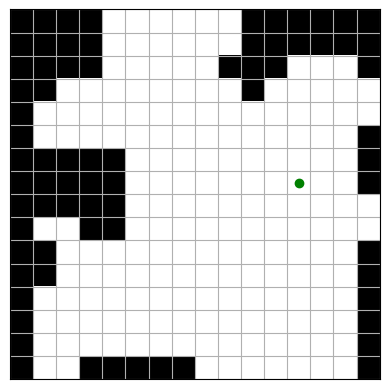

In [207]:
gen = WRPDataGenerator(16, 16)
grid, start = gen.generate_simple_polygon_grid()


# start = (0, 0)  # Starting at the top-left corner
plot_grid(grid, start)  # Plot the grid from the first channel of the input

Success! Entire polygon explored in 94 steps.
Success! Entire polygon explored in 89 steps.
Success! Entire polygon explored in 64 steps.


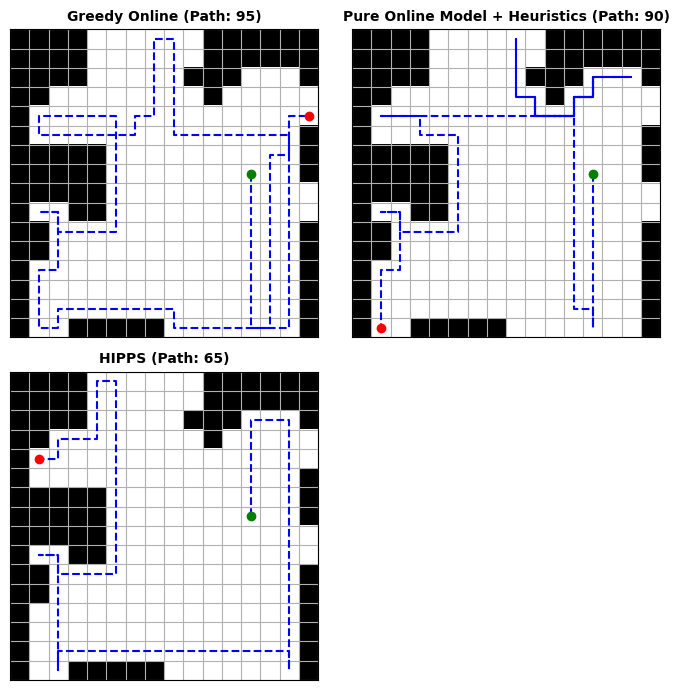

In [215]:
fig, axes = plt.subplots(2, 2, figsize=(7, 7))

# Algorithm 1: Greedy Online
path_pred_line1, data_ = pred_path_greedy_online(trained_model, grid, start)
plt.sca(axes[0, 0])
plot_path(grid, path_pred_line1)
axes[0, 0].set_title(f"Greedy Online (Path: {len(path_pred_line1)})", fontsize=10, fontweight='bold')

# Algorithm 2: Receding Horizon A*
path_pred_line = receding_horizon_astar_online(trained_model, grid, start)
plt.sca(axes[0, 1])
plot_path(grid, path_pred_line)
axes[0, 1].set_title(f"Pure Online Model + Heuristics (Path: {len(path_pred_line)})", fontsize=10, fontweight='bold')

# Algorithm 3: HIPPS
path_pred_line = hipps_algorithm(trained_model, grid, start)
plt.sca(axes[1, 0])
plot_path(grid, path_pred_line)
axes[1, 0].set_title(f"HIPPS (Path: {len(path_pred_line)})", fontsize=10, fontweight='bold')

# Keep the 2x2 layout clean when only 3 plots are used
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

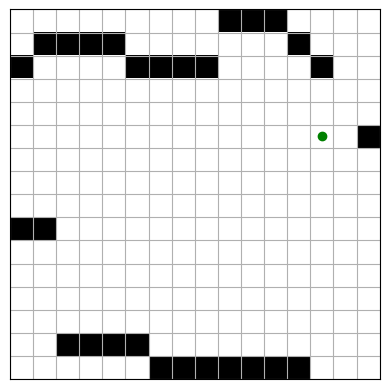

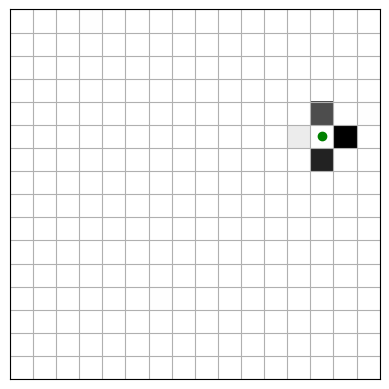

In [110]:
step = 18
plot_grid(data_[0][step][0][0], path_pred_line1[step])
plot_grid(data_[1][step],  path_pred_line1[step])

Optimized Path Length: 26
Lower Bound:  30.727272727272727


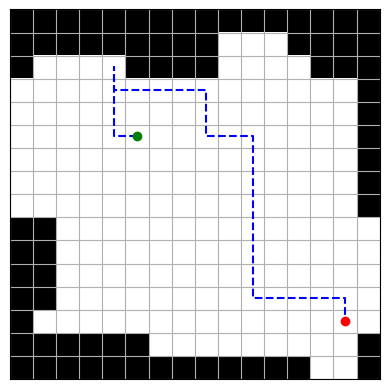

In [111]:
solver_opt = WRPSolverTSPJF(grid, start)
path_opt, cnt_opt = solve_wrp_tsp_jf(solver_opt)
print("Optimized Path Length:", len(path_opt))
lower_bound = len(path_opt) * 13/11
print("Lower Bound: ", lower_bound)
plot_path(grid, path_opt, start)

## Evaluation

In [150]:
def evaluate_model_on_random_grids(model, polygon_type = "simple_polygon", user_neural_search=True, num_samples=5):
     model.eval()
     grid_size = (16, 16)
     gt_path_lengths = []
     pred_path_lengths = []
     pred_path_lengths_search = []
     pred_path_lengths_hipps = []
     # pred_path_lengths_visibility = []

     for i in tqdm(range(num_samples)):
          gen = WRPDataGenerator(*grid_size)
          grid, start = None, None
          if polygon_type == "holes":
               grid, start = gen.generate_valid_grid(density=5)
          elif polygon_type == "simple_polygon":
               grid, start = gen.generate_simple_polygon_grid()
          # grid, start = gen.generate_valid_grid(density=0.2)
          # grid, start = gen.generate_simple_polygon_grid(density=0.2)

          solver_opt = WRPSolverTSPJF(grid, start)
          path_opt, _ = solve_wrp_tsp_jf(solver_opt)

          path_pred_line, _ = pred_path_greedy_online(model, grid, start, max_steps=256, verbose=False)
          if (user_neural_search):
               path_pred_line_search = receding_horizon_astar_online(model, grid, start, verbose=False)
          hipps_pred_line = hipps_algorithm(model, grid, start, verbose=False)
          

          gt_path_lengths.append(len(path_opt))
          pred_path_lengths.append(len(path_pred_line))
          pred_path_lengths_hipps.append(len(hipps_pred_line))
          
          if user_neural_search: 
               pred_path_lengths_search.append(len(path_pred_line_search))

     rmse = np.sqrt(np.mean([(gt - pred) ** 2 for gt, pred in zip(gt_path_lengths, pred_path_lengths)]))
     print(f"\nAverage Ground Truth Path Length: {np.mean(gt_path_lengths):.2f}")
     print(f"Average Predicted Path Length: {np.mean(pred_path_lengths):.2f}")
     print(f"Root Mean Squared Error in Path Lengths: {rmse:.2f}") 

     print("Ground Truth Path Length:  ", gt_path_lengths)
     print("Model Predict Path Length: ", pred_path_lengths)
     # print("Visibility Predict Path Length: ", pred_path_lengths_visibility)
     if user_neural_search:
          print("Neural Search Path Length: ", pred_path_lengths_search)
          return np.array(gt_path_lengths), np.array(pred_path_lengths), np.array(pred_path_lengths_search), np.array(pred_path_lengths_hipps)
     return np.array(gt_path_lengths), np.array(pred_path_lengths), None , np.array(pred_path_lengths_hipps)

In [151]:
gt_path_lengths, pred_path_lengths, pred_path_lengths_search, pred_path_lengths_hipps= evaluate_model_on_random_grids(trained_model, num_samples=100)


100%|██████████| 100/100 [19:16<00:00, 11.56s/it] 


Average Ground Truth Path Length: 34.61
Average Predicted Path Length: 81.95
Root Mean Squared Error in Path Lengths: 77.46
Ground Truth Path Length:   [31, 33, 35, 26, 31, 39, 31, 20, 26, 25, 29, 36, 65, 32, 27, 56, 33, 27, 58, 37, 32, 44, 38, 46, 27, 27, 31, 49, 28, 25, 43, 37, 19, 48, 23, 28, 24, 21, 55, 34, 34, 28, 19, 31, 42, 30, 31, 43, 22, 50, 26, 36, 38, 34, 37, 56, 32, 60, 16, 27, 39, 45, 30, 30, 31, 34, 21, 34, 23, 28, 55, 23, 48, 27, 39, 39, 23, 40, 32, 35, 30, 39, 42, 34, 59, 35, 53, 24, 41, 43, 28, 31, 53, 25, 38, 43, 36, 20, 18, 25]
Model Predict Path Length:  [49, 40, 88, 26, 43, 76, 137, 27, 34, 48, 50, 40, 102, 128, 48, 71, 70, 41, 124, 39, 39, 53, 58, 257, 45, 35, 50, 191, 66, 52, 60, 57, 21, 121, 28, 33, 38, 89, 200, 34, 50, 42, 21, 257, 60, 70, 64, 85, 36, 257, 56, 257, 84, 44, 87, 257, 36, 201, 16, 53, 57, 129, 66, 49, 50, 50, 28, 71, 31, 30, 172, 24, 70, 31, 257, 61, 26, 91, 59, 183, 53, 45, 257, 88, 213, 43, 78, 40, 197, 257, 47, 87, 82, 34, 55, 76, 79, 32, 22, 

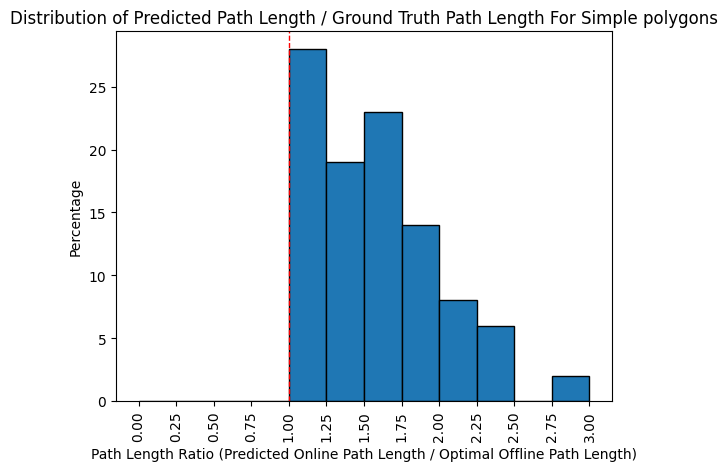

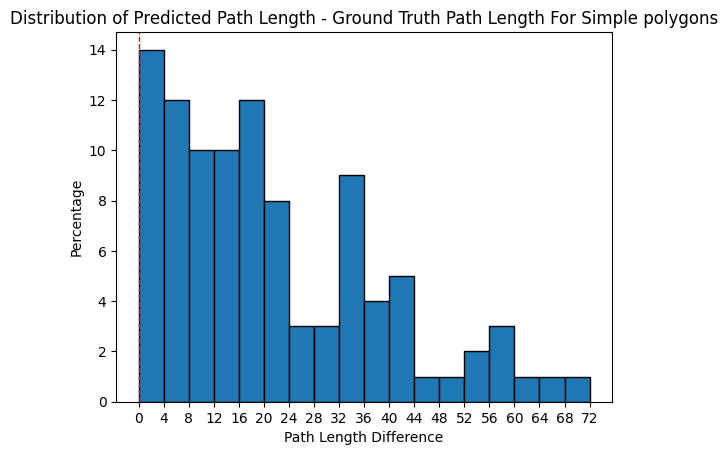

In [157]:
path_len_diff = np.minimum(pred_path_lengths, pred_path_lengths_search) - gt_path_lengths
path_len_ratio = np.minimum(pred_path_lengths, pred_path_lengths_search) / gt_path_lengths
# path_len_ratio = pred_path_lengths/ gt_path_lengths
max_diff = np.max(path_len_diff)
# path_len_diff = np.array([i if i >= 0 else max_diff + 1 for i in path_len_diff])
#bin width of 5 


step = 0.25
plt.hist(path_len_ratio, edgecolor='black', bins=np.arange(0, path_len_ratio.max() + step, step))
plt.title("Distribution of Predicted Path Length / Ground Truth Path Length For Simple polygons")
plt.xlabel("Path Length Ratio (Predicted Online Path Length / Optimal Offline Path Length)")
plt.ylabel("Percentage")
plt.xticks(np.arange(0, path_len_ratio.max() + step, step))
plt.xticks(rotation=90)

plt.axvline(1, color='red', linestyle='dashed', linewidth=1)
plt.show()

step = 4
plt.hist(path_len_diff, edgecolor='black', bins=np.arange(path_len_diff.min(), path_len_diff.max() + step, step))
plt.title("Distribution of Predicted Path Length - Ground Truth Path Length For Simple polygons")
plt.xlabel("Path Length Difference")
plt.ylabel("Percentage")
plt.xticks(np.arange(path_len_diff.min(), path_len_diff.max() + step, step))
#rotate x-axis labels by 45 degrees
plt.axvline(0, color='red', linestyle='dashed', linewidth=1)
plt.show()

In [528]:
save_evaluation_results(gt_path_lengths, pred_path_lengths, pred_path_lengths_search, "", filename="evaluation_results/evaluation_results_online_simple_polygon.npz")

Saved evaluation results to evaluation_results/evaluation_results_online_simple_polygon.npz


In [529]:
gt_lengths1, pred_lengths_model1, pred_lengths_search1, pred_lengths_visibility1 = load_evaluation_results(filename="evaluation_results/evaluation_results_online_simple_polygon.npz")

Loaded evaluation results from evaluation_results/evaluation_results_online_simple_polygon.npz
